# Predictive Modeling

### Setup   

In [137]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
import geopandas as gpd

# 1. Load in data

In [17]:
# paths
base_dir = Path("/Users/hannahmaihojgaard/Documents/GitHub/datascience2026")
data_path = base_dir / "forecasting_data"

In [20]:
# load data
daily_taxi = pd.read_csv(data_path / "daily_taxi_2013_2025.csv")

# preprocess date column
daily_taxi["date"] = pd.to_datetime(daily_taxi["date"])

# sort by date
daily_taxi = daily_taxi.sort_values("date").reset_index(drop=True)

daily_taxi.head()

,date,trip_count,avg_fare,total_fare,avg_total_amount,total_revenue,avg_distance,avg_duration,avg_tip,avg_passengers,source_file
0,2013-01-01,409050,12.725598,5205405.78,14.777094,6044570.15,3.375243,11.163758,1.068419,1.838066,2013-01
1,2013-01-02,389841,11.896467,4637730.76,14.138408,5511731.00,3.029305,11.230170,1.107561,1.715692,2013-01
2,2013-01-03,438155,11.465754,5023777.66,13.654552,5982810.04,2.789965,11.300080,1.116355,1.697518,2013-01
3,2013-01-04,475467,11.201410,5325900.58,13.375566,6359640.39,2.676159,11.121728,1.117325,1.708968,2013-01
4,2013-01-05,470595,11.224734,5282303.60,13.164564,6195177.81,2.765861,10.669944,1.074380,1.783281,2013-01


In [21]:
print("Start date:", daily_taxi["date"].min())
print("End date:", daily_taxi["date"].max())
print("Rows:", daily_taxi.shape[0])
print("Duplicate dates:", daily_taxi["date"].duplicated().sum())

Start date: 2013-01-01 00:00:00
End date: 2025-12-31 00:00:00
Rows: 4748
Duplicate dates: 0


In [22]:
full_date_range = pd.date_range(
    start=daily_taxi["date"].min(),
    end=daily_taxi["date"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(daily_taxi["date"])

print("Expected days:", len(full_date_range))
print("Actual days:", len(daily_taxi))
print("Missing days:", len(missing_dates))

missing_dates[:20]

Expected days: 4748
Actual days: 4748
Missing days: 0


DatetimeIndex([], dtype='datetime64[ns]', freq='D')

# 2. Feature Engineering

In [ ]:
# create date features
daily_taxi["year"] = daily_taxi["date"].dt.year

daily_taxi["month"] = daily_taxi["date"].dt.month

daily_taxi["day"] = daily_taxi["date"].dt.day

daily_taxi["day_of_week"] = daily_taxi["date"].dt.dayofweek

daily_taxi["day_name"] = daily_taxi["date"].dt.day_name()

daily_taxi["week_of_year"] = daily_taxi["date"].dt.isocalendar().week

daily_taxi["quarter"] = daily_taxi["date"].dt.quarter

daily_taxi["is_weekend"] = (
    daily_taxi["day_of_week"] >= 5
).astype(int)

In [ ]:
# check the new features
daily_taxi[[
    "date",
    "trip_count",
    "day_of_week",
    "day_name",
    "month",
    "quarter",
    "is_weekend"
]].head(10)

,date,trip_count,day_of_week,day_name,month,quarter,is_weekend
0,2013-01-01,409050,1,Tuesday,1,1,0
1,2013-01-02,389841,2,Wednesday,1,1,0
2,2013-01-03,438155,3,Thursday,1,1,0
3,2013-01-04,475467,4,Friday,1,1,0
4,2013-01-05,470595,5,Saturday,1,1,1
5,2013-01-06,400525,6,Sunday,1,1,1
6,2013-01-07,404467,0,Monday,1,1,0
7,2013-01-08,438833,1,Tuesday,1,1,0
8,2013-01-09,454484,2,Wednesday,1,1,0
9,2013-01-10,485043,3,Thursday,1,1,0


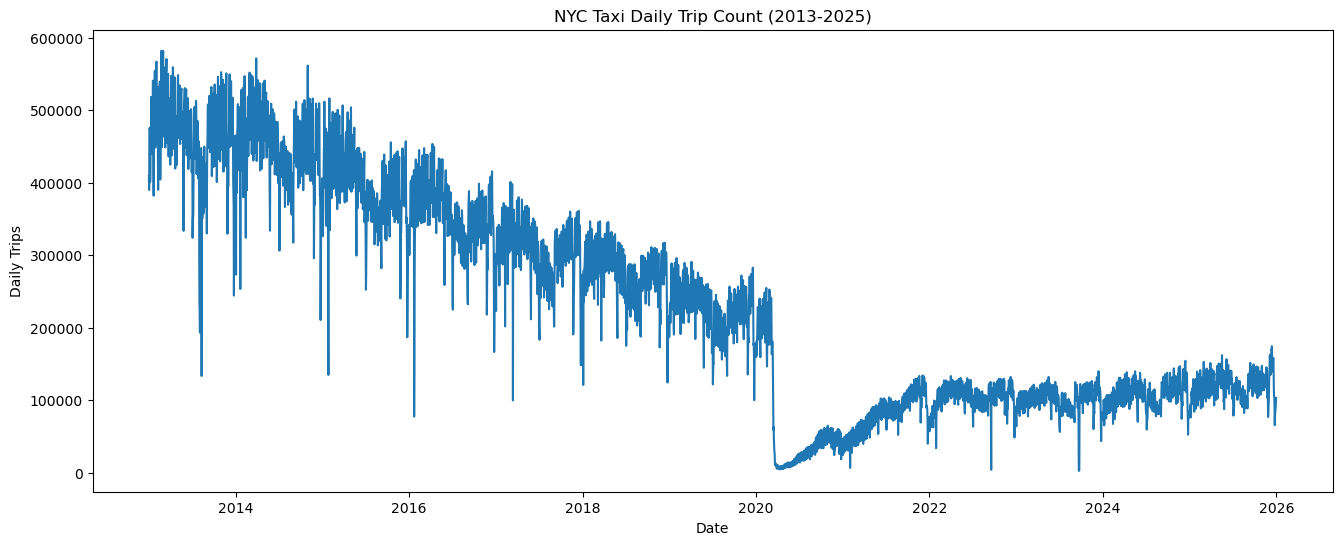

In [ ]:
#demand plotzzz
plt.figure(figsize=(16,6))

plt.plot(
    daily_taxi["date"],
    daily_taxi["trip_count"]
)

plt.title("NYC Taxi Daily Trip Count (2013-2025)")

plt.xlabel("Date")

plt.ylabel("Daily Trips")

plt.show()

## Smoothing the signal

In [28]:
# add rolling averages
daily_taxi["trip_count_7d"] = (
    daily_taxi["trip_count"]
    .rolling(window=7)
    .mean()
)

In [29]:
daily_taxi["trip_count_30d"] = (
    daily_taxi["trip_count"]
    .rolling(window=30)
    .mean()
)

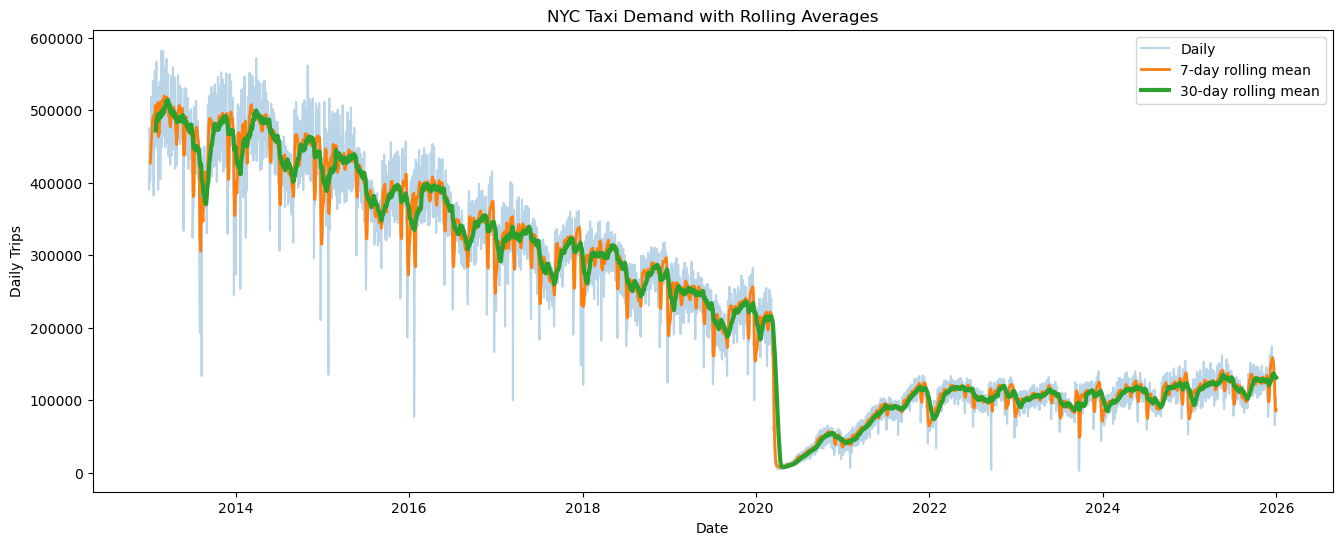

In [ ]:
# plot with rolling averages
plt.figure(figsize=(16,6))

plt.plot(
    daily_taxi["date"],
    daily_taxi["trip_count"],
    alpha=0.3,
    label="Daily"
)

plt.plot(
    daily_taxi["date"],
    daily_taxi["trip_count_7d"],
    linewidth=2,
    label="7-day rolling mean"
)

plt.plot(
    daily_taxi["date"],
    daily_taxi["trip_count_30d"],
    linewidth=3,
    label="30-day rolling mean"
)

plt.title("NYC Taxi Demand with Rolling Averages")

plt.xlabel("Date")

plt.ylabel("Daily Trips")

plt.legend()

plt.show()

# More EDA

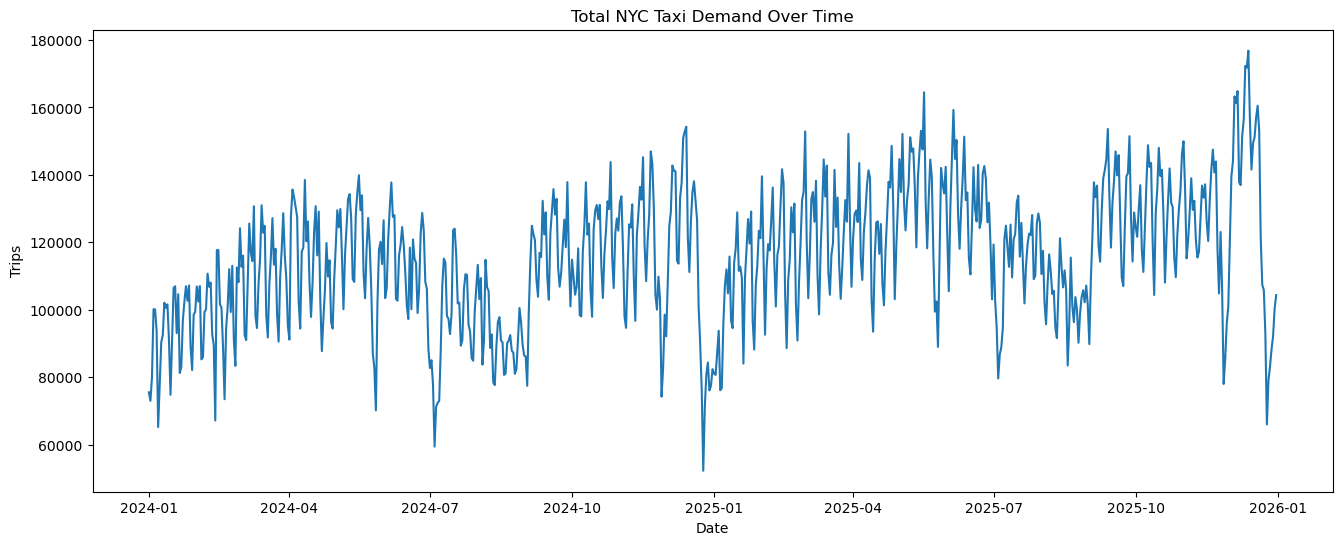

In [ ]:
daily_total = (
    zone_daily
    .groupby("date")["trip_count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

plt.plot(
    daily_total["date"],
    daily_total["trip_count"]
)

plt.title("Total NYC Taxi Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.show()

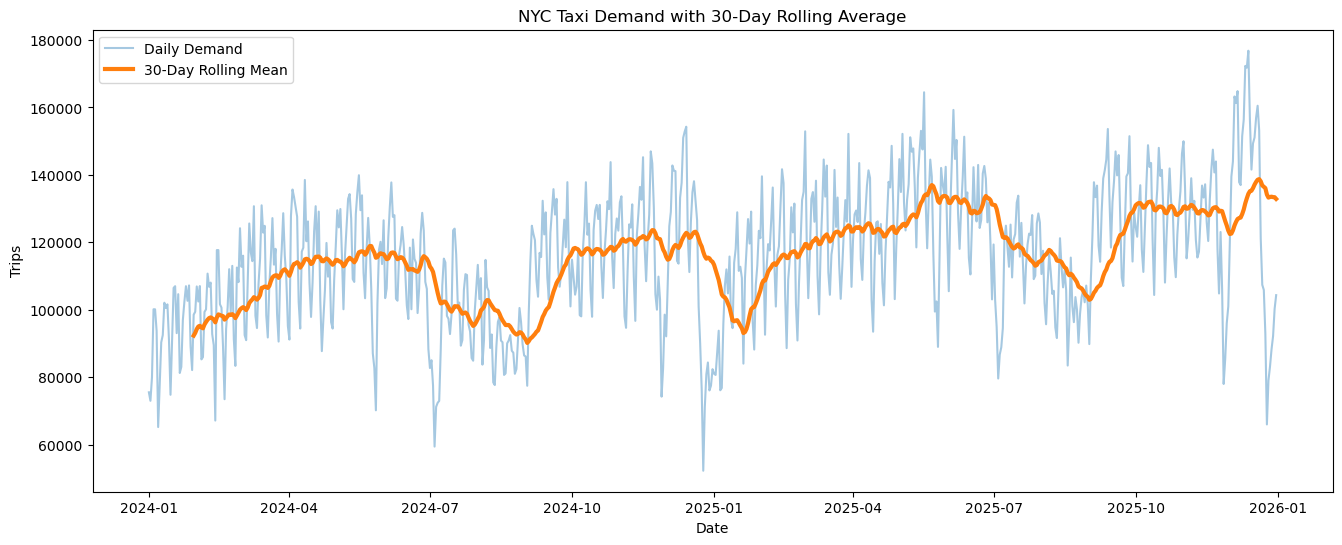

In [ ]:
daily_total["rolling_30"] = (
    daily_total["trip_count"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(16,6))

plt.plot(
    daily_total["date"],
    daily_total["trip_count"],
    alpha=0.4,
    label="Daily Demand"
)

plt.plot(
    daily_total["date"],
    daily_total["rolling_30"],
    linewidth=3,
    label="30-Day Rolling Mean"
)

plt.title("NYC Taxi Demand with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.legend()

plt.show()

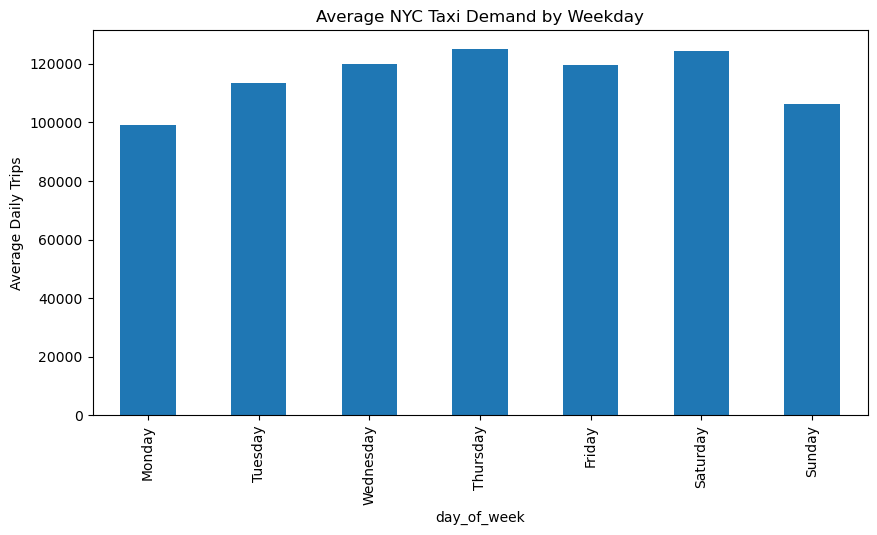

In [ ]:
daily_total["day_of_week"] = (
    daily_total["date"]
    .dt.day_name()
)

weekday_avg = (
    daily_total
    .groupby("day_of_week")["trip_count"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

plt.figure(figsize=(10,5))

weekday_avg.plot(kind="bar")

plt.title("Average NYC Taxi Demand by Weekday")
plt.ylabel("Average Daily Trips")

plt.show()

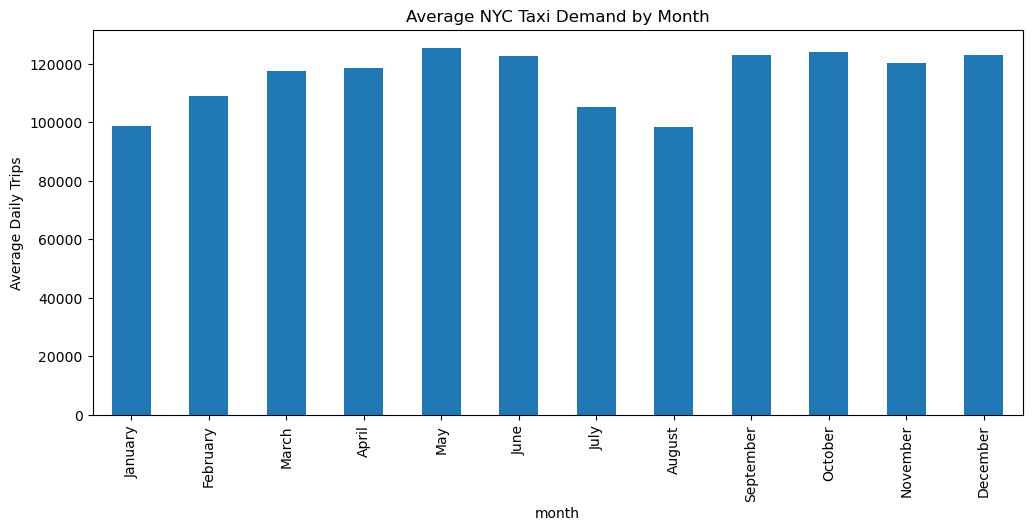

In [ ]:
daily_total["month"] = (
    daily_total["date"]
    .dt.month_name()
)

monthly_avg = (
    daily_total
    .groupby("month")["trip_count"]
    .mean()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)

plt.figure(figsize=(12,5))

monthly_avg.plot(kind="bar")

plt.title("Average NYC Taxi Demand by Month")
plt.ylabel("Average Daily Trips")

plt.show()

In [ ]:
baseline_pred = zone_2026_df["lag_1"]

baseline_mae = mean_absolute_error(
    y_zone_2026,
    baseline_pred
)

baseline_rmse = root_mean_squared_error(
    y_zone_2026,
    baseline_pred
)

print("Naive Baseline")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

Naive Baseline
MAE: 105.76
RMSE: 323.86


# Time-series Decomposition

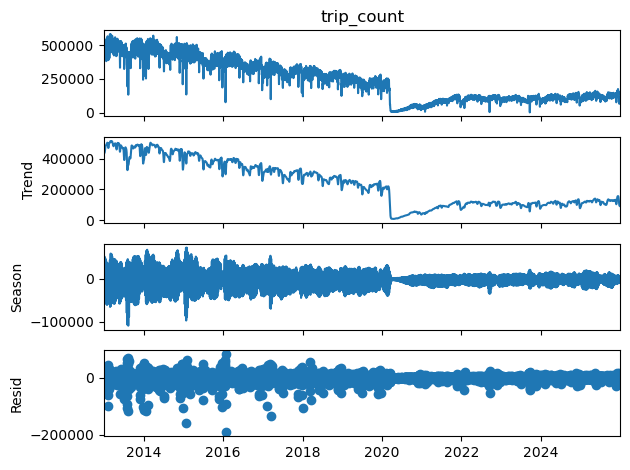

In [266]:

ts = daily_taxi.set_index("date")["trip_count"]

stl = STL(ts, period=7)
result = stl.fit()

result.plot()
plt.show()

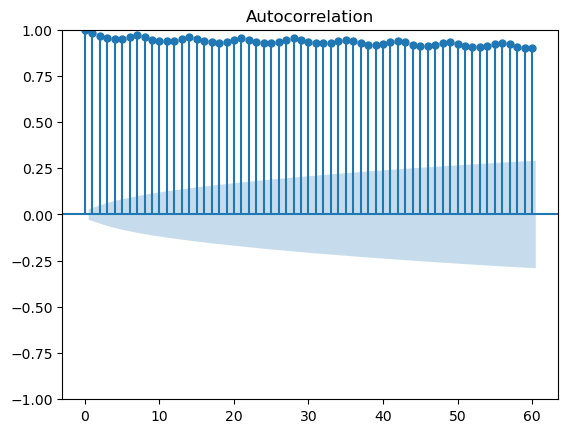

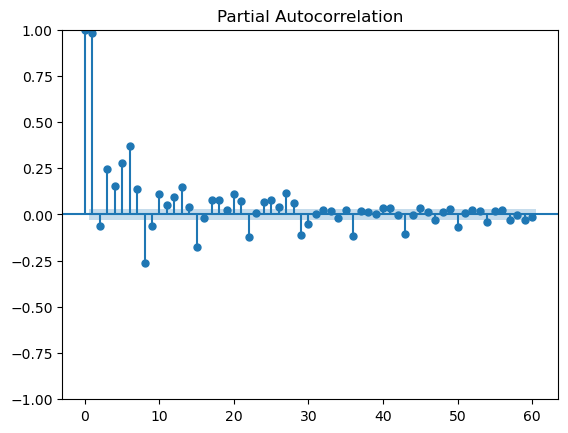

In [267]:
#ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf       

plot_acf(ts, lags=60)
plt.show()

plot_pacf(ts, lags=60)
plt.show()

## Lag Features

In [35]:
daily_taxi["lag_1"] = (
    daily_taxi["trip_count"]
    .shift(1)
)

daily_taxi["lag_7"] = (
    daily_taxi["trip_count"]
    .shift(7)
)

daily_taxi["lag_30"] = (
    daily_taxi["trip_count"]
    .shift(30)
)

| Feature | Meaning                            |
| ------- | ---------------------------------- |
| lag_1   | yesterday’s trips                  |
| lag_7   | same weekday last week             |
| lag_30  | approximately same time last month |


In [36]:
# add rolling mean and std (shifted to avoid data leakage)
daily_taxi["rolling_mean_7"] = (
    daily_taxi["trip_count"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_taxi["rolling_std_7"] = (
    daily_taxi["trip_count"]
    .shift(1)
    .rolling(7)
    .std()
)

daily_taxi["rolling_mean_30"] = (
    daily_taxi["trip_count"]
    .shift(1)
    .rolling(30)
    .mean()
)

Notice:
.shift(1) before rolling bc of data leakage.  Without it, the model would accidentally see the target value itself. The model never sees future information.

In [37]:
daily_taxi[[
    "date",
    "trip_count",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_std_7"
]].head(40)

,date,trip_count,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7
0,2013-01-01,409050,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,389841,409050.0,NaN,NaN,NaN,NaN
2,2013-01-03,438155,389841.0,NaN,NaN,NaN,NaN
3,2013-01-04,475467,438155.0,NaN,NaN,NaN,NaN
4,2013-01-05,470595,475467.0,NaN,NaN,NaN,NaN
5,2013-01-06,400525,470595.0,NaN,NaN,NaN,NaN
6,2013-01-07,404467,400525.0,NaN,NaN,NaN,NaN
7,2013-01-08,438833,404467.0,409050.0,NaN,426871.428571,34846.204766
8,2013-01-09,454484,438833.0,389841.0,NaN,431126.142857,34118.190746
9,2013-01-10,485043,454484.0,438155.0,NaN,440360.857143,29519.689680


In [38]:
# prepare final dataset for forecasting
forecast_df = daily_taxi.dropna().copy()

forecast_df.shape


(4718, 27)

Target is: trip_count

Everything else becomes predictors/features.


In [39]:
#Feature columns to use for forecasting

feature_cols = [

    # Calendar features
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",

    # Lag features
    "lag_1",
    "lag_7",
    "lag_30",

    # Rolling statistics
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_30"

]

target_col = "trip_count"

# Train/test split

Temporal train/test split



Training = 2013–2024

Test = 2025

True final holdout: 2026 Q1 comes later.

In [40]:
train_df = forecast_df[
    forecast_df["date"] < "2025-01-01"
].copy()

test_df = forecast_df[
    forecast_df["date"] >= "2025-01-01"
].copy()

print("Train rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])

print("\nTrain period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTest period:")
print(test_df["date"].min(), "to", test_df["date"].max())

Train rows: 4353
Test rows: 365

Train period:
2013-01-31 00:00:00 to 2024-12-31 00:00:00

Test period:
2025-01-01 00:00:00 to 2025-12-31 00:00:00


# ML matrices

Separate:

features (X)
target (y)

In [41]:
X_train = train_df[feature_cols]

y_train = train_df[target_col]

X_test = test_df[feature_cols]

y_test = test_df[target_col]

In [42]:
# sanity check shapes
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(4353, 13)
(4353,)
(365, 13)
(365,)


# Baseline: Naive Forecast

The simplest possible forecast: yhat(t) = y(t)-1

Meaning: tomorrow’s trips = today’s trips

In [43]:
naive_pred = test_df["lag_1"]

In [45]:
# evaluate naive forecast
naive_mae = mean_absolute_error(
    y_test,
    naive_pred
)

naive_rmse = root_mean_squared_error(
    y_test,
    naive_pred
)

print("Naive Forecast Performance")
print(f"MAE: {naive_mae:,.2f}")
print(f"RMSE: {naive_rmse:,.2f}")

Naive Forecast Performance
MAE: 11,218.41
RMSE: 13,365.90


# Linear Regression Forecast

Do lag and rolling features improve prediction beyond naive persistence?

In [50]:
# train linear regression model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [51]:
lr_pred = lr_model.predict(X_test)

In [52]:
# evaluate linear regression forecast
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = root_mean_squared_error(
    y_test,
    lr_pred
)

print("Linear Regression Performance")
print(f"MAE: {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")

Linear Regression Performance
MAE: 10,145.62
RMSE: 12,845.88


## Compare linear regression forecast to naive forecast

In [53]:
results = pd.DataFrame({

    "Model": [
        "Naive Forecast",
        "Linear Regression"
    ],

    "MAE": [
        naive_mae,
        lr_mae
    ],

    "RMSE": [
        naive_rmse,
        lr_rmse
    ]

})

results

,Model,MAE,RMSE
0,Naive Forecast,11218.413699,13365.903415
1,Linear Regression,10145.618531,12845.875426


## Visualize Predictions vs. Reality

In [54]:
comparison_df = pd.DataFrame({

    "date": test_df["date"],

    "actual": y_test,

    "naive_pred": naive_pred,

    "lr_pred": lr_pred

})

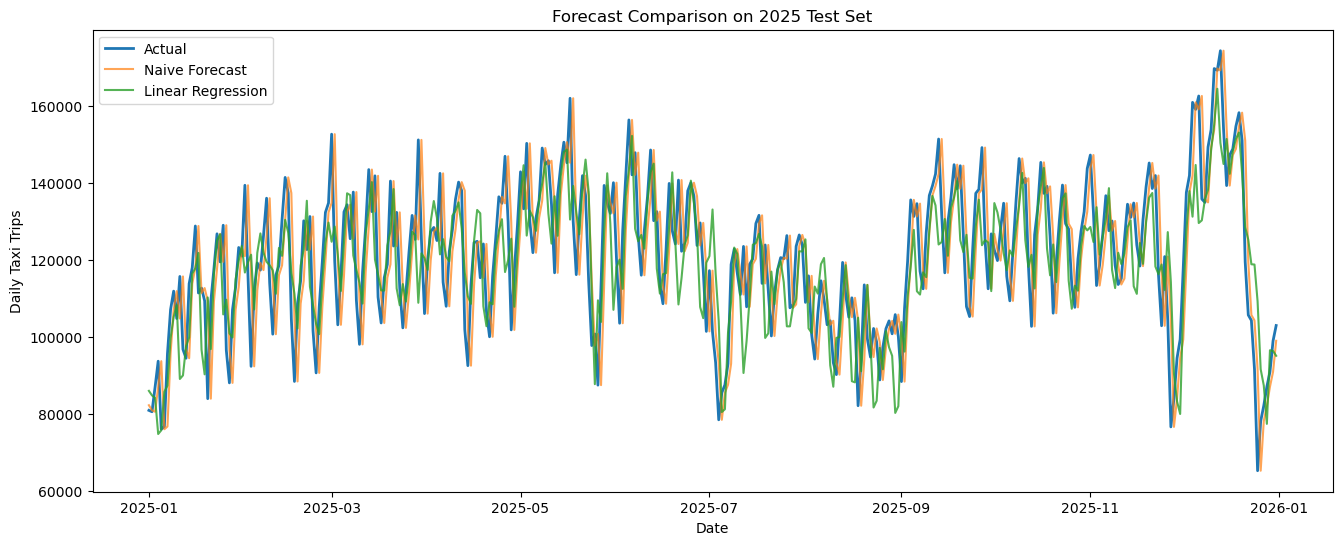

In [265]:
#all the plotzzz
plt.figure(figsize=(16,6))

plt.plot(
    comparison_df["date"],
    comparison_df["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison_df["date"],
    comparison_df["naive_pred"],
    label="Naive Forecast",
    alpha=0.7
)

plt.plot(
    comparison_df["date"],
    comparison_df["lr_pred"],
    label="Linear Regression",
    alpha=0.8
)

plt.title("Forecast Comparison on 2025 Test Set")

plt.xlabel("Date")

plt.ylabel("Daily Taxi Trips")

plt.legend()

plt.show()

# Random Forest Forecast

In [56]:
from sklearn.ensemble import RandomForestRegressor

In [57]:
rf_model = RandomForestRegressor(

    n_estimators=100,

    max_depth=15,

    min_samples_leaf=5,

    random_state=42,

    n_jobs=-1
)

In [58]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                      random_state=42)

| Parameter          | Purpose              |
| ------------------ | -------------------- |
| n_estimators=100   | number of trees      |
| max_depth=15       | prevents overfitting |
| min_samples_leaf=5 | smoother predictions |
| n_jobs=-1          | uses all CPU cores   |


Same forecast settings as from the paper

In [59]:
rf_pred = rf_model.predict(X_test)

In [60]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = root_mean_squared_error(
    y_test,
    rf_pred
)

print("Random Forest Performance")
print(f"MAE: {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")

Random Forest Performance
MAE: 8,120.96
RMSE: 10,266.45


In [61]:
results = pd.DataFrame({

    "Model": [
        "Naive Forecast",
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        naive_mae,
        lr_mae,
        rf_mae
    ],

    "RMSE": [
        naive_rmse,
        lr_rmse,
        rf_rmse
    ]

})

results

,Model,MAE,RMSE
0,Naive Forecast,11218.413699,13365.903415
1,Linear Regression,10145.618531,12845.875426
2,Random Forest,8120.961122,10266.454511


# Feature Importance Analysis

In [62]:
feature_importance = pd.DataFrame({

    "feature": feature_cols,

    "importance": rf_model.feature_importances_

})

In [63]:
feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

feature_importance

,feature,importance
7,lag_1,0.878410
10,rolling_mean_7,0.068784
12,rolling_mean_30,0.025893
8,lag_7,0.017348
3,day_of_week,0.004364
9,lag_30,0.001445
11,rolling_std_7,0.001106
4,week_of_year,0.000853
2,day,0.000754
6,is_weekend,0.000585


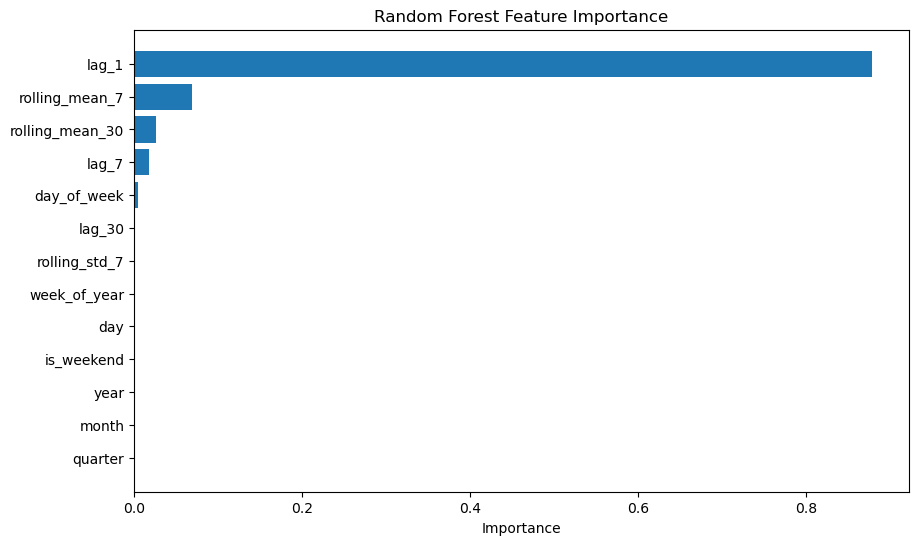

In [64]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

# XGBoost model

In [ ]:
#!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 4.4 MB/s eta 0:00:0000:0100:01


In [67]:
from xgboost import XGBRegressor

In [68]:
xgb_model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    objective="reg:squarederror"
)

| Parameter            | Purpose                      |
| -------------------- | ---------------------------- |
| n_estimators=300     | many boosting rounds         |
| learning_rate=0.05   | slower, more stable learning |
| max_depth=6          | avoids overfitting           |
| subsample=0.8        | regularization               |
| colsample_bytree=0.8 | feature randomness           |



In [69]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [70]:
xgb_pred = xgb_model.predict(X_test)

In [71]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = root_mean_squared_error(
    y_test,
    xgb_pred
)

print("XGBoost Performance")
print(f"MAE: {xgb_mae:,.2f}")
print(f"RMSE: {xgb_rmse:,.2f}")

XGBoost Performance
MAE: 7,171.67
RMSE: 9,132.80


In [72]:
results = pd.DataFrame({

    "Model": [
        "Naive Forecast",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        naive_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        naive_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]

})

results

,Model,MAE,RMSE
0,Naive Forecast,11218.413699,13365.903415
1,Linear Regression,10145.618531,12845.875426
2,Random Forest,8120.961122,10266.454511
3,XGBoost,7171.667744,9132.795536


# HistGradientBoostingRegressor

In [73]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [74]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

In [75]:
hgb_model.fit(X_train, y_train)

HistGradientBoostingRegressor(l2_regularization=0.1, learning_rate=0.05,
                              max_iter=500, random_state=42)

In [76]:
hgb_pred = hgb_model.predict(X_test)

In [77]:
hgb_mae = mean_absolute_error(
    y_test,
    hgb_pred
)

hgb_rmse = root_mean_squared_error(
    y_test,
    hgb_pred
)

print("HistGradientBoosting Performance")
print(f"MAE: {hgb_mae:,.2f}")
print(f"RMSE: {hgb_rmse:,.2f}")

HistGradientBoosting Performance
MAE: 6,914.26
RMSE: 8,637.59


In [78]:
results = pd.DataFrame({

    "Model": [
        "Naive Forecast",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "HistGradientBoosting"
    ],

    "MAE": [
        naive_mae,
        lr_mae,
        rf_mae,
        xgb_mae,
        hgb_mae
    ],

    "RMSE": [
        naive_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        hgb_rmse
    ]

})

results

,Model,MAE,RMSE
0,Naive Forecast,11218.413699,13365.903415
1,Linear Regression,10145.618531,12845.875426
2,Random Forest,8120.961122,10266.454511
3,XGBoost,7171.667744,9132.795536
4,HistGradientBoosting,6914.258346,8637.591884


# Walk-forawrd validation

| Train Period | Test Year |
| ------------ | --------- |
| 2013–2019    | 2020      |
| 2013–2020    | 2021      |
| 2013–2021    | 2022      |
| 2013–2022    | 2023      |
| 2013–2023    | 2024      |
| 2013–2024    | 2025      |


In [82]:
validation_years = [
    2020,
    2021,
    2022,
    2023,
    2024,
    2025
]

In [83]:
wf_results = []

In [84]:
for year in validation_years:

    # TRAIN
    train_wf = forecast_df[
        forecast_df["date"].dt.year < year
    ]

    # TEST
    test_wf = forecast_df[
        forecast_df["date"].dt.year == year
    ]

    # Features/targets
    X_train_wf = train_wf[feature_cols]
    y_train_wf = train_wf[target_col]

    X_test_wf = test_wf[feature_cols]
    y_test_wf = test_wf[target_col]

    # Model
    model = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )

    # Fit
    model.fit(X_train_wf, y_train_wf)

    # Predict
    pred_wf = model.predict(X_test_wf)

    # Metrics
    mae = mean_absolute_error(
        y_test_wf,
        pred_wf
    )

    rmse = root_mean_squared_error(
        y_test_wf,
        pred_wf
    )

    # Store
    wf_results.append({
        "test_year": year,
        "mae": mae,
        "rmse": rmse
    })

    print(f"Finished {year}")

Finished 2020
Finished 2021
Finished 2022
Finished 2023
Finished 2024
Finished 2025


In [85]:
wf_results_df = pd.DataFrame(wf_results)

wf_results_df

,test_year,mae,rmse
0,2020,114380.532100,127085.434100
1,2021,21215.798647,24409.239424
2,2022,5491.344556,9253.341200
3,2023,5567.152198,9134.303088
4,2024,6608.577525,8564.557155
5,2025,6914.258346,8637.591884


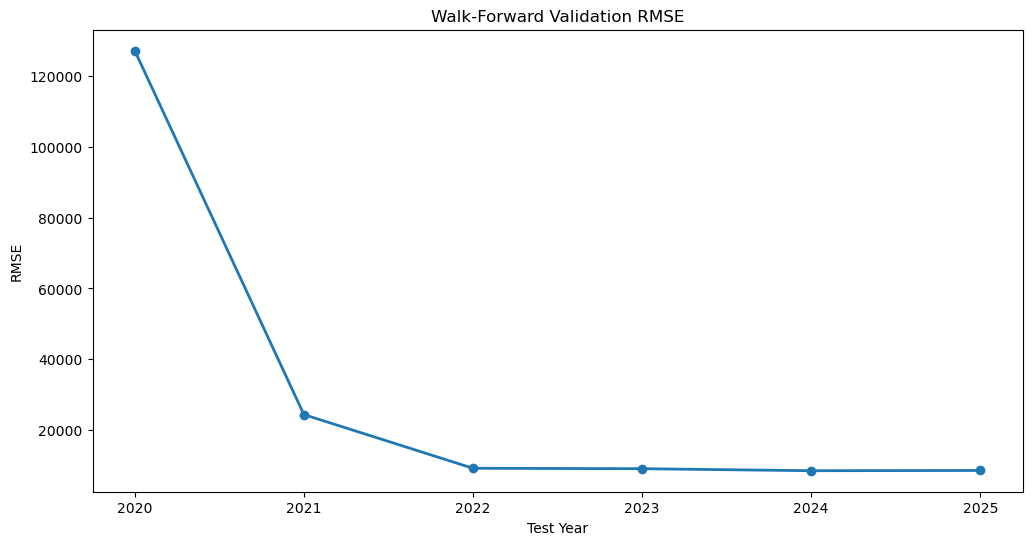

In [86]:
plt.figure(figsize=(12,6))

plt.plot(
    wf_results_df["test_year"],
    wf_results_df["rmse"],
    marker="o",
    linewidth=2
)

plt.title("Walk-Forward Validation RMSE")

plt.xlabel("Test Year")

plt.ylabel("RMSE")

plt.xticks(wf_results_df["test_year"])

plt.show()

# External Variables

In [91]:
oil_df = pd.read_csv(
    data_path / "DCOILBRENTEU.csv"
)

oil_df.head()

,observation_date,DCOILBRENTEU
0,2013-01-02,112.98
1,2013-01-03,113.03
2,2013-01-04,112.58
3,2013-01-07,112.49
4,2013-01-08,113.03


In [97]:
oil_df.columns = [
    "date",
    "oil_price"
]

oil_df["date"] = pd.to_datetime(
    oil_df["date"]
)

oil_df["oil_price"] = pd.to_numeric(
    oil_df["oil_price"],
    errors="coerce"
)

oil_df.head()

,date,oil_price
0,2013-01-02,112.98
1,2013-01-03,113.03
2,2013-01-04,112.58
3,2013-01-07,112.49
4,2013-01-08,113.03


In [98]:
print(
    oil_df["oil_price"].isna().sum()
)

0


Forward-fill missing prices

Oil prices change slowly enough that forward filling is reasonable.

In [99]:
oil_df["oil_price"] = (
    oil_df["oil_price"]
    .ffill()
)

In [100]:
oil_df.head()

,date,oil_price
0,2013-01-02,112.98
1,2013-01-03,113.03
2,2013-01-04,112.58
3,2013-01-07,112.49
4,2013-01-08,113.03


In [101]:
forecast_oil_df = forecast_df.merge(

    oil_df,

    on="date",

    how="left"
)

forecast_oil_df.head()

,date,trip_count,avg_fare,total_fare,avg_total_amount,total_revenue,avg_distance,avg_duration,avg_tip,avg_passengers,...,is_weekend,trip_count_7d,trip_count_30d,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,oil_price
0,2013-01-31,528124,11.755557,6208391.77,14.238425,7519654.21,2.734583,12.223175,1.391266,1.663337,...,0,498100.857143,475786.866667,479644.0,528783.0,409050.0,498195.000000,40155.858053,471817.733333,115.55
1,2013-02-01,563828,11.770944,6636787.89,14.162242,7985068.37,2.682828,12.342858,1.325384,1.691282,...,0,502371.285714,481586.433333,528124.0,533935.0,389841.0,498100.857143,40072.881256,475786.866667,115.55
2,2013-02-02,566865,11.089300,6286136.16,13.061381,7404039.79,2.596671,11.108198,1.144107,1.774636,...,1,504168.571429,485876.766667,563828.0,554284.0,438155.0,502371.285714,45722.588264,481586.433333,NaN
3,2013-02-03,469775,11.579877,5439936.89,13.716678,6443752.31,2.958706,10.378322,1.242842,1.742743,...,1,504450.000000,485687.033333,566865.0,467805.0,475467.0,504168.571429,48279.098465,485876.766667,NaN
4,2013-02-04,454231,11.631488,5283382.58,14.063930,6388272.92,2.785324,11.514417,1.334858,1.648762,...,0,505304.714286,485141.566667,469775.0,448248.0,470595.0,504450.000000,48036.933891,485687.033333,116.06


### Adding holidays

In [102]:
from pandas.tseries.holiday import USFederalHolidayCalendar

In [103]:
calendar = USFederalHolidayCalendar()

holidays = calendar.holidays(
    start=forecast_oil_df["date"].min(),
    end=forecast_oil_df["date"].max()
)

In [104]:
forecast_oil_df["is_holiday"] = (
    forecast_oil_df["date"]
    .isin(holidays)
    .astype(int)
)

In [105]:
forecast_oil_df[
    forecast_oil_df["is_holiday"] == 1
][["date", "is_holiday"]].head(20)

,date,is_holiday
18,2013-02-18,1
116,2013-05-27,1
154,2013-07-04,1
214,2013-09-02,1
256,2013-10-14,1
284,2013-11-11,1
301,2013-11-28,1
328,2013-12-25,1
335,2014-01-01,1
354,2014-01-20,1


In [106]:
#Add feautes    
feature_cols_external = (
    feature_cols
    + ["oil_price", "is_holiday"]
)

In [109]:
forecast_oil_df[feature_cols_external].isna().sum()

year               0
month              0
day                0
day_of_week        0
week_of_year       0
quarter            0
is_weekend         0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_std_7      0
rolling_mean_30    0
oil_price          0
is_holiday         0
dtype: int64

In [108]:
forecast_oil_df["oil_price"] = (
    forecast_oil_df["oil_price"]
    .ffill()
    .bfill()
)

# Retraining with external features

In [110]:
train_external_df = forecast_oil_df[
    forecast_oil_df["date"] < "2025-01-01"
].copy()

test_external_df = forecast_oil_df[
    forecast_oil_df["date"] >= "2025-01-01"
].copy()

In [111]:
X_train_external = train_external_df[feature_cols_external]
y_train_external = train_external_df[target_col]

X_test_external = test_external_df[feature_cols_external]
y_test_external = test_external_df[target_col]

In [112]:
hgb_external_model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

hgb_external_model.fit(
    X_train_external,
    y_train_external
)

HistGradientBoostingRegressor(l2_regularization=0.1, learning_rate=0.05,
                              max_iter=500, random_state=42)

In [113]:
hgb_external_pred = hgb_external_model.predict(
    X_test_external
)

hgb_external_mae = mean_absolute_error(
    y_test_external,
    hgb_external_pred
)

hgb_external_rmse = root_mean_squared_error(
    y_test_external,
    hgb_external_pred
)

print("HistGradientBoosting + External Variables")
print(f"MAE: {hgb_external_mae:,.2f}")
print(f"RMSE: {hgb_external_rmse:,.2f}")

HistGradientBoosting + External Variables
MAE: 8,173.36
RMSE: 10,145.07


In [114]:
external_comparison = pd.DataFrame({

    "Model": [
        "HistGradientBoosting",
        "HistGradientBoosting + Oil + Holidays"
    ],

    "MAE": [
        hgb_mae,
        hgb_external_mae
    ],

    "RMSE": [
        hgb_rmse,
        hgb_external_rmse
    ]

})

external_comparison

,Model,MAE,RMSE
0,HistGradientBoosting,6914.258346,8637.591884
1,HistGradientBoosting + Oil + Holidays,8173.364864,10145.074999


# Forecasting 2026 Q1

In [127]:
future_2026_df = pd.read_csv(
    data_path / "daily_taxi_2026_q1.csv"
)

future_2026_df["date"] = pd.to_datetime(
    future_2026_df["date"]
)

In [128]:
combined_future_df = pd.concat([
    forecast_df,
    future_2026_df
])

combined_future_df = (
    combined_future_df
    .sort_values("date")
    .reset_index(drop=True)
)

combined_future_df.shape

(4808, 27)

In [129]:
# Lag features
combined_future_df["lag_1"] = (
    combined_future_df["trip_count"]
    .shift(1)
)

combined_future_df["lag_7"] = (
    combined_future_df["trip_count"]
    .shift(7)
)

combined_future_df["lag_30"] = (
    combined_future_df["trip_count"]
    .shift(30)
)

# Rolling features
combined_future_df["rolling_mean_7"] = (
    combined_future_df["trip_count"]
    .shift(1)
    .rolling(7)
    .mean()
)

combined_future_df["rolling_std_7"] = (
    combined_future_df["trip_count"]
    .shift(1)
    .rolling(7)
    .std()
)

combined_future_df["rolling_mean_30"] = (
    combined_future_df["trip_count"]
    .shift(1)
    .rolling(30)
    .mean()
)

# Calendar features
combined_future_df["year"] = (
    combined_future_df["date"].dt.year
)

combined_future_df["month"] = (
    combined_future_df["date"].dt.month
)

combined_future_df["day"] = (
    combined_future_df["date"].dt.day
)

combined_future_df["day_of_week"] = (
    combined_future_df["date"].dt.dayofweek
)

combined_future_df["week_of_year"] = (
    combined_future_df["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

combined_future_df["quarter"] = (
    combined_future_df["date"].dt.quarter
)

combined_future_df["is_weekend"] = (
    combined_future_df["day_of_week"] >= 5
).astype(int)

In [130]:
forecast_2026_df = combined_future_df[
    combined_future_df["date"].dt.year == 2026
].copy()

forecast_2026_df.shape

(90, 27)

In [131]:
forecast_2026_df[feature_cols].isna().sum()

year               0
month              0
day                0
day_of_week        0
week_of_year       0
quarter            0
is_weekend         0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_std_7      0
rolling_mean_30    0
dtype: int64

## Predict 2026 Q1

In [132]:
X_2026 = forecast_2026_df[feature_cols]

y_2026_actual = forecast_2026_df["trip_count"]

y_2026_pred = hgb_model.predict(X_2026)

In [133]:
mae_2026 = mean_absolute_error(
    y_2026_actual,
    y_2026_pred
)

rmse_2026 = root_mean_squared_error(
    y_2026_actual,
    y_2026_pred
)

print("2026 Q1 Forecast Performance")
print(f"MAE: {mae_2026:,.2f}")
print(f"RMSE: {rmse_2026:,.2f}")

2026 Q1 Forecast Performance
MAE: 7,320.02
RMSE: 13,710.60


In [134]:
residuals_2025 = (
    y_test - hgb_pred
)

residual_std = residuals_2025.std()

print(residual_std)

8310.934109068126


In [135]:
upper_band = (
    y_2026_pred
    + 1.96 * residual_std
)

lower_band = (
    y_2026_pred
    - 1.96 * residual_std
)

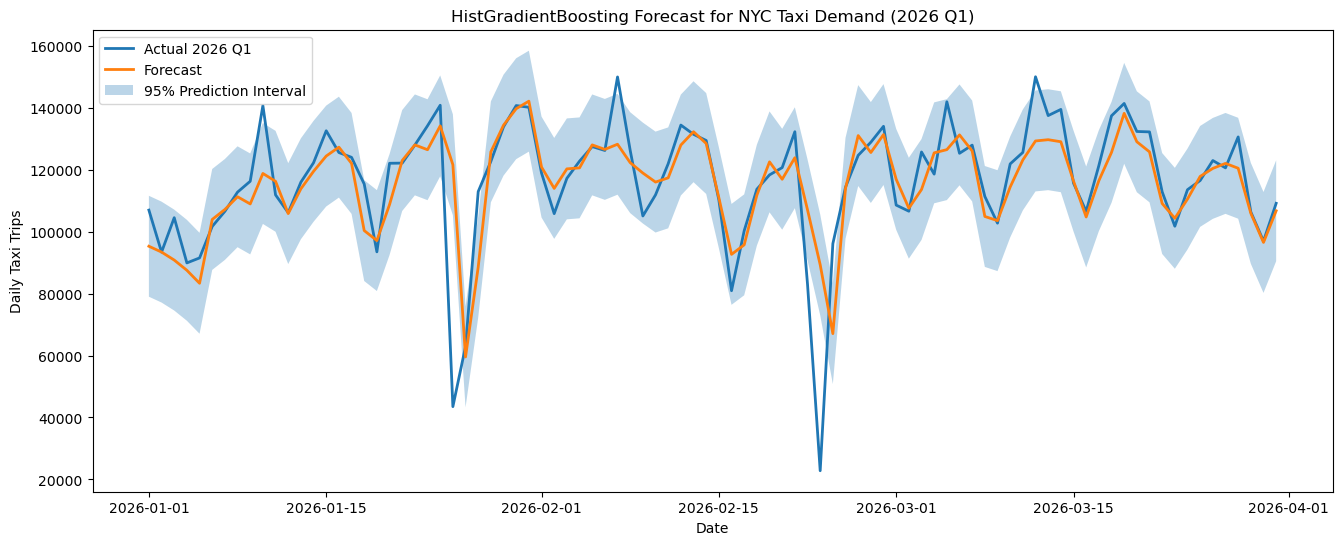

In [136]:
plt.figure(figsize=(16,6))

# Actual demand
plt.plot(
    forecast_2026_df["date"],
    y_2026_actual,
    label="Actual 2026 Q1",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_2026_df["date"],
    y_2026_pred,
    label="Forecast",
    linewidth=2
)

# Uncertainty interval
plt.fill_between(
    forecast_2026_df["date"],
    lower_band,
    upper_band,
    alpha=0.3,
    label="95% Prediction Interval"
)

plt.title(
    "HistGradientBoosting Forecast for NYC Taxi Demand (2026 Q1)"
)

plt.xlabel("Date")
plt.ylabel("Daily Taxi Trips")

plt.legend()

plt.show()

# Creating Spatial Analysis Data

In [138]:
shape_path = (
    data_path /
    "taxi_zones" /
    "taxi_zones.shp"
)

zones_gdf = gpd.read_file(shape_path)

zones_gdf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


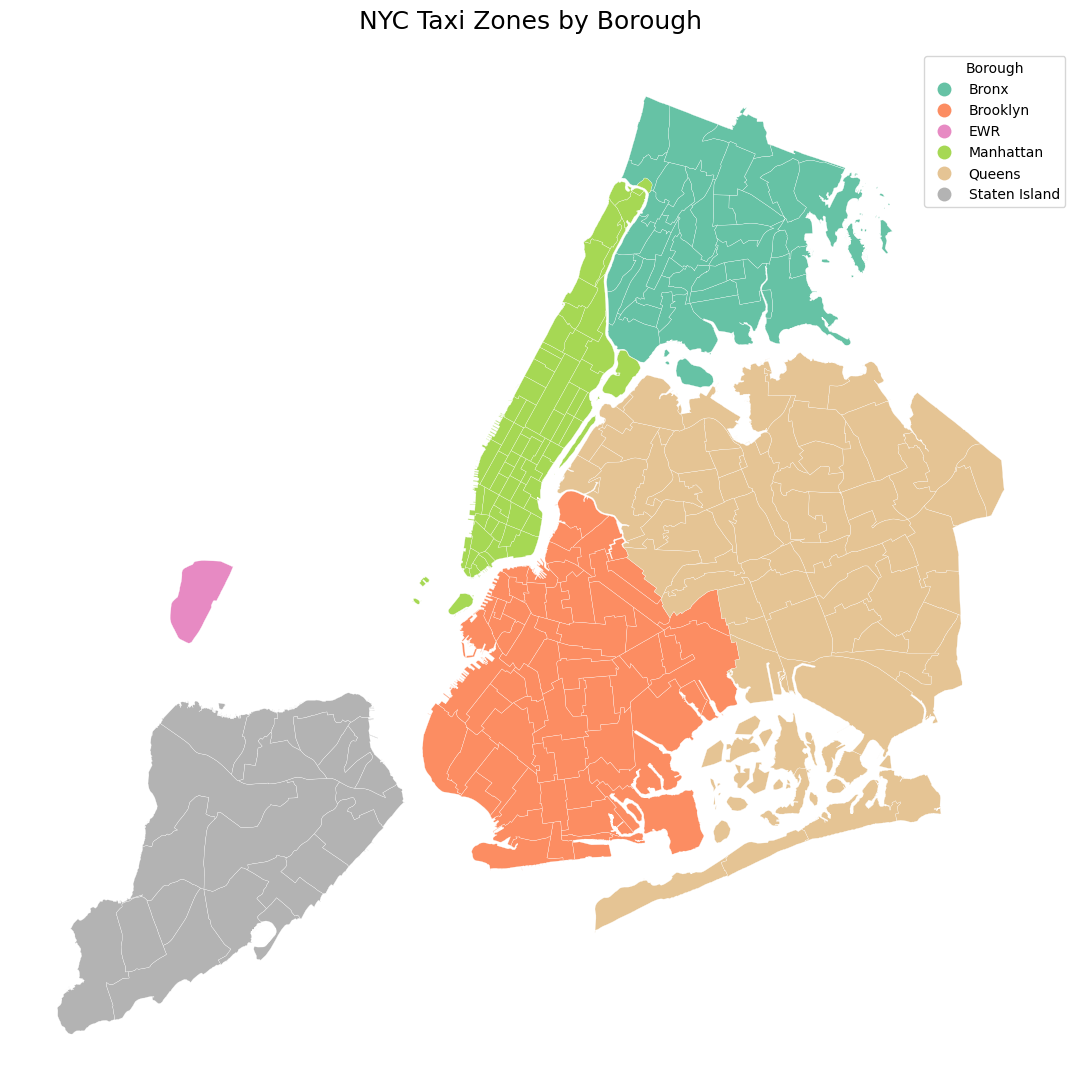

In [139]:
fig, ax = plt.subplots(figsize=(11, 11))

zones_gdf.plot(
    ax=ax,
    column="borough",
    categorical=True,
    cmap="Set2",
    linewidth=0.2,
    edgecolor="white",
    legend=True
)

ax.set_title(
    "NYC Taxi Zones by Borough",
    fontsize=18,
    pad=15
)

ax.axis("off")

legend = ax.get_legend()

legend.set_bbox_to_anchor((1.02, 1))
legend.set_title("Borough")

plt.tight_layout()

plt.show()

In [151]:
spatial_files = sorted(
    data_path.glob("yellow_tripdata_202[45]-*.parquet")
)

len(spatial_files), spatial_files[:3], spatial_files[-3:]

(24,
 [PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2024-01.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2024-02.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2024-03.parquet')],
 [PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2025-10.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2025-11.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2025-12.parquet')])

In [152]:
zone_daily_dfs = []

for file in spatial_files:
    
    print(f"Processing {file.name}")

    df = pd.read_parquet(file)

    file_month = file.stem.replace("yellow_tripdata_", "")

    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

    # Keep only trips from the file's actual month
    df = df[
        df["tpep_pickup_datetime"].dt.to_period("M").astype(str) == file_month
    ].copy()

    # Basic cleaning
    df = df[
        (df["trip_distance"] > 0) &
        (df["fare_amount"] > 0) &
        (df["PULocationID"].notna())
    ].copy()

    df["date"] = df["tpep_pickup_datetime"].dt.date
    df["date"] = pd.to_datetime(df["date"])

    daily_zone = (
        df
        .groupby(["date", "PULocationID"])
        .agg(
            trip_count=("tpep_pickup_datetime", "count"),
            avg_fare=("fare_amount", "mean"),
            avg_distance=("trip_distance", "mean")
        )
        .reset_index()
    )

    zone_daily_dfs.append(daily_zone)

zone_daily = pd.concat(zone_daily_dfs, ignore_index=True)

zone_daily.head()

Processing yellow_tripdata_2024-01.parquet
Processing yellow_tripdata_2024-02.parquet
Processing yellow_tripdata_2024-03.parquet
Processing yellow_tripdata_2024-04.parquet
Processing yellow_tripdata_2024-05.parquet
Processing yellow_tripdata_2024-06.parquet
Processing yellow_tripdata_2024-07.parquet
Processing yellow_tripdata_2024-08.parquet
Processing yellow_tripdata_2024-09.parquet
Processing yellow_tripdata_2024-10.parquet
Processing yellow_tripdata_2024-11.parquet
Processing yellow_tripdata_2024-12.parquet
Processing yellow_tripdata_2025-01.parquet
Processing yellow_tripdata_2025-02.parquet
Processing yellow_tripdata_2025-03.parquet
Processing yellow_tripdata_2025-04.parquet
Processing yellow_tripdata_2025-05.parquet
Processing yellow_tripdata_2025-06.parquet
Processing yellow_tripdata_2025-07.parquet
Processing yellow_tripdata_2025-08.parquet
Processing yellow_tripdata_2025-09.parquet
Processing yellow_tripdata_2025-10.parquet
Processing yellow_tripdata_2025-11.parquet
Processing 

,date,PULocationID,trip_count,avg_fare,avg_distance
0,2024-01-01,1,5,79.400000,3.426000
1,2024-01-01,3,1,35.270000,9.660000
2,2024-01-01,4,178,21.718596,3.668202
3,2024-01-01,7,143,27.381608,5.282657
4,2024-01-01,9,3,53.266667,14.126667


In [178]:
zone_lookup = pd.read_csv(
    data_path / "taxi_zones" / "taxi_zone_lookup.csv"
)

zone_daily = zone_daily.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_daily.head()

,date,PULocationID,trip_count,avg_fare,avg_distance,LocationID_x,Borough_x,Zone_x,service_zone_x,LocationID_y,Borough_y,Zone_y,service_zone_y,LocationID,Borough,Zone,service_zone
0,2024-01-01,1,5,79.400000,3.426000,1,EWR,Newark Airport,EWR,1,EWR,Newark Airport,EWR,1,EWR,Newark Airport,EWR
1,2024-01-01,3,1,35.270000,9.660000,3,Bronx,Allerton/Pelham Gardens,Boro Zone,3,Bronx,Allerton/Pelham Gardens,Boro Zone,3,Bronx,Allerton/Pelham Gardens,Boro Zone
2,2024-01-01,4,178,21.718596,3.668202,4,Manhattan,Alphabet City,Yellow Zone,4,Manhattan,Alphabet City,Yellow Zone,4,Manhattan,Alphabet City,Yellow Zone
3,2024-01-01,7,143,27.381608,5.282657,7,Queens,Astoria,Boro Zone,7,Queens,Astoria,Boro Zone,7,Queens,Astoria,Boro Zone
4,2024-01-01,9,3,53.266667,14.126667,9,Queens,Auburndale,Boro Zone,9,Queens,Auburndale,Boro Zone,9,Queens,Auburndale,Boro Zone


In [160]:
zone_daily.columns

Index(['date', 'PULocationID', 'trip_count', 'avg_fare', 'avg_distance',
       'LocationID_x', 'Borough_x', 'Zone_x', 'service_zone_x', 'LocationID_y',
       'Borough_y', 'Zone_y', 'service_zone_y'],
      dtype='object')

In [161]:
all_dates = pd.date_range(
    start=zone_daily["date"].min(),
    end=zone_daily["date"].max(),
    freq="D"
)

all_zones = zone_daily["PULocationID"].unique()

full_index = pd.MultiIndex.from_product(
    [all_dates, all_zones],
    names=["date", "PULocationID"]
)

zone_panel = (
    zone_daily
    .set_index(["date", "PULocationID"])
    .reindex(full_index)
    .reset_index()
)

zone_panel["trip_count"] = zone_panel["trip_count"].fillna(0)

In [162]:
zone_panel = zone_panel.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_panel.head()

,date,PULocationID,trip_count,avg_fare,avg_distance,LocationID_x,Borough_x,Zone_x,service_zone_x,LocationID_y,Borough_y,Zone_y,service_zone_y,LocationID,Borough,Zone,service_zone
0,2024-01-01,1,5.0,79.400000,3.426000,1.0,EWR,Newark Airport,EWR,1.0,EWR,Newark Airport,EWR,1,EWR,Newark Airport,EWR
1,2024-01-01,3,1.0,35.270000,9.660000,3.0,Bronx,Allerton/Pelham Gardens,Boro Zone,3.0,Bronx,Allerton/Pelham Gardens,Boro Zone,3,Bronx,Allerton/Pelham Gardens,Boro Zone
2,2024-01-01,4,178.0,21.718596,3.668202,4.0,Manhattan,Alphabet City,Yellow Zone,4.0,Manhattan,Alphabet City,Yellow Zone,4,Manhattan,Alphabet City,Yellow Zone
3,2024-01-01,7,143.0,27.381608,5.282657,7.0,Queens,Astoria,Boro Zone,7.0,Queens,Astoria,Boro Zone,7,Queens,Astoria,Boro Zone
4,2024-01-01,9,3.0,53.266667,14.126667,9.0,Queens,Auburndale,Boro Zone,9.0,Queens,Auburndale,Boro Zone,9,Queens,Auburndale,Boro Zone


In [163]:
zone_panel = (
    zone_panel
    .sort_values(["PULocationID", "date"])
    .reset_index(drop=True)
)

zone_panel["lag_1"] = (
    zone_panel
    .groupby("PULocationID")["trip_count"]
    .shift(1)
)

zone_panel["lag_7"] = (
    zone_panel
    .groupby("PULocationID")["trip_count"]
    .shift(7)
)

zone_panel["rolling_mean_7"] = (
    zone_panel
    .groupby("PULocationID")["trip_count"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

zone_panel["day_of_week"] = zone_panel["date"].dt.dayofweek
zone_panel["month"] = zone_panel["date"].dt.month
zone_panel["is_weekend"] = (zone_panel["day_of_week"] >= 5).astype(int)

In [164]:
zone_panel_model = zone_panel.dropna(
    subset=[
        "lag_1",
        "lag_7",
        "rolling_mean_7",
        "Zone",
        "Borough"
    ]
).copy()

zone_panel_model.shape

(188964, 23)

In [165]:
from sklearn.preprocessing import LabelEncoder

borough_encoder = LabelEncoder()

zone_panel_model["borough_encoded"] = borough_encoder.fit_transform(
    zone_panel_model["Borough"]
)

zone_encoder = LabelEncoder()

zone_panel_model["zone_encoded"] = zone_encoder.fit_transform(
    zone_panel_model["Zone"]
)

In [171]:
spatial_train = zone_panel_model[
    zone_panel_model["date"] < "2025-01-01"
].copy()

spatial_test = zone_panel_model[
    zone_panel_model["date"] >= "2025-01-01"
].copy()

print("Train:", spatial_train.shape)
print("Test:", spatial_test.shape)

Train: (93699, 25)
Test: (95265, 25)


In [167]:
spatial_features = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "day_of_week",
    "month",
    "is_weekend",
    "borough_encoded",
    "zone_encoded"
]

X_spatial_train = spatial_train[spatial_features]
y_spatial_train = spatial_train["trip_count"]

X_spatial_test = spatial_test[spatial_features]
y_spatial_test = spatial_test["trip_count"]

In [168]:
spatial_hgb = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

spatial_hgb.fit(
    X_spatial_train,
    y_spatial_train
)

HistGradientBoostingRegressor(learning_rate=0.05, max_depth=8, max_iter=300,
                              random_state=42)

In [169]:
spatial_pred = spatial_hgb.predict(X_spatial_test)

spatial_mae = mean_absolute_error(
    y_spatial_test,
    spatial_pred
)

spatial_rmse = root_mean_squared_error(
    y_spatial_test,
    spatial_pred
)

print("Spatio-Temporal Forecast Performance")
print(f"MAE: {spatial_mae:,.2f}")
print(f"RMSE: {spatial_rmse:,.2f}")

Spatio-Temporal Forecast Performance
MAE: 47.23
RMSE: 140.66


In [172]:
zone_panel_model[
    [
        "date",
        "PULocationID",
        "trip_count",
        "lag_1",
        "lag_7",
        "rolling_mean_7"
    ]
].head(20)

,date,PULocationID,trip_count,lag_1,lag_7,rolling_mean_7
7,2024-01-08,1,4.0,2.0,5.0,2.714286
8,2024-01-09,1,1.0,4.0,2.0,2.571429
9,2024-01-10,1,2.0,1.0,5.0,2.428571
10,2024-01-11,1,1.0,2.0,4.0,2.000000
11,2024-01-12,1,3.0,1.0,1.0,1.571429
12,2024-01-13,1,0.0,3.0,0.0,1.857143
13,2024-01-14,1,2.0,0.0,2.0,1.857143
14,2024-01-15,1,2.0,2.0,4.0,1.857143
15,2024-01-16,1,2.0,2.0,1.0,1.571429
16,2024-01-17,1,0.0,2.0,2.0,1.714286


In [173]:
spatial_test["date"].min()

Timestamp('2025-01-01 00:00:00')

In [174]:
y_spatial_test.describe()

count    95265.000000
mean       468.357896
std       1082.441381
min          0.000000
25%         10.000000
50%         32.000000
75%        175.000000
max       9571.000000
Name: trip_count, dtype: float64

In [175]:
spatial_test = spatial_test.copy()

spatial_test["predicted_trip_count"] = spatial_pred

spatial_test["residual"] = (
    spatial_test["trip_count"]
    - spatial_test["predicted_trip_count"]
)

In [176]:
zone_results = (
    spatial_test
    .groupby(
        ["PULocationID", "Zone", "Borough"]
    )
    .agg(
        actual_trips=("trip_count", "sum"),
        predicted_trips=("predicted_trip_count", "sum"),
        mean_residual=("residual", "mean")
    )
    .reset_index()
)

zone_results.head()

,PULocationID,Zone,Borough,actual_trips,predicted_trips,mean_residual
0,1,Newark Airport,EWR,1339.0,1531.393261,-0.527105
1,2,Jamaica Bay,Queens,60.0,636.253686,-1.578777
2,3,Allerton/Pelham Gardens,Bronx,4272.0,4268.213825,0.010373
3,4,Alphabet City,Manhattan,129641.0,124511.970136,14.052137
4,5,Arden Heights,Staten Island,10.0,636.253686,-1.715764


In [180]:
taxi_zones = gpd.read_file(
    data_path / "taxi_zones" / "taxi_zones.shp"
)

zone_map = taxi_zones.merge(
    zone_results,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

In [187]:
zone_map["log_actual_trips"] = np.log1p(zone_map["actual_trips"])
zone_map["log_predicted_trips"] = np.log1p(zone_map["predicted_trips"])

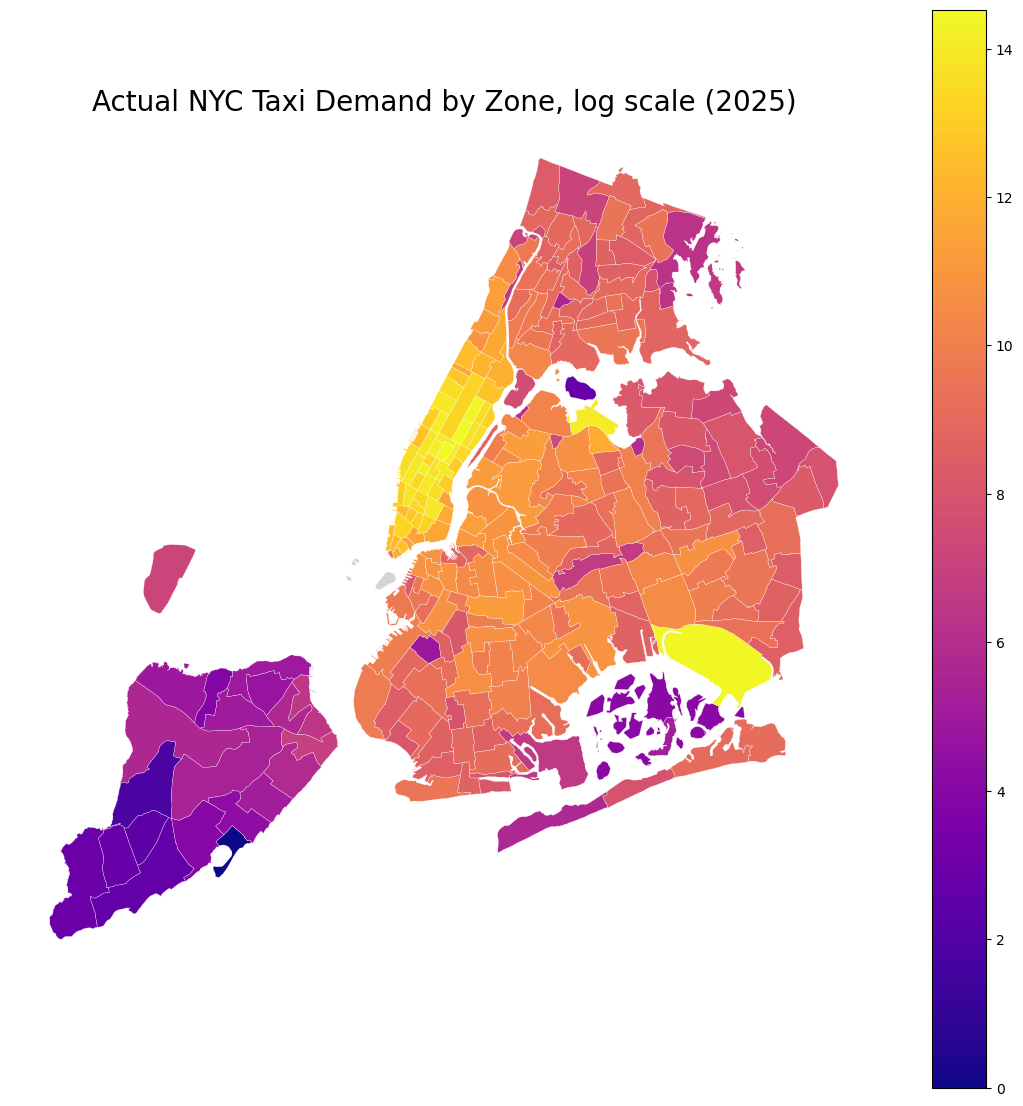

In [188]:
fig, ax = plt.subplots(figsize=(14, 14))

zone_map.plot(
    column="log_actual_trips",
    cmap="plasma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Actual NYC Taxi Demand by Zone, log scale (2025)", fontsize=20)
ax.axis("off")

plt.show()

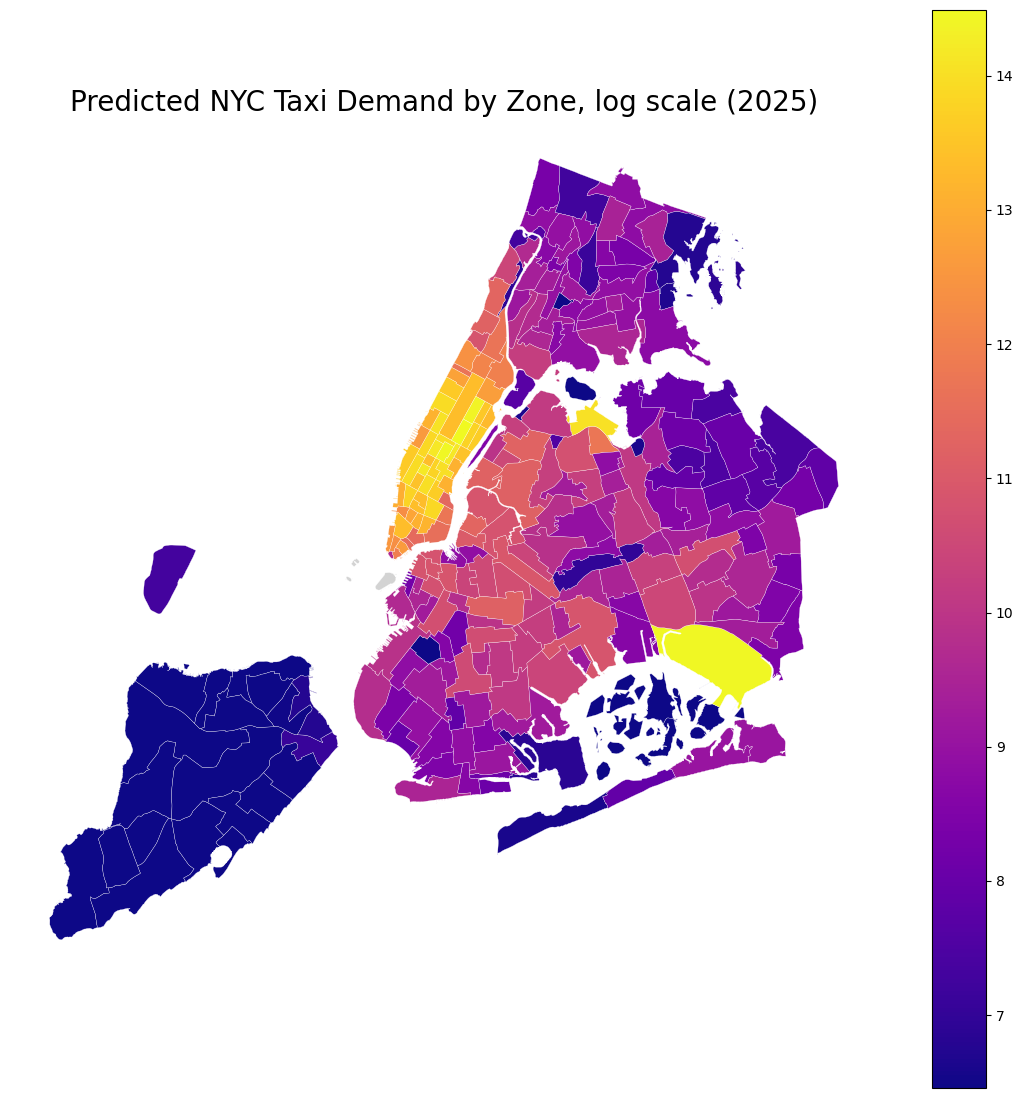

In [189]:
fig, ax = plt.subplots(figsize=(14, 14))

zone_map.plot(
    column="log_predicted_trips",
    cmap="plasma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Predicted NYC Taxi Demand by Zone, log scale (2025)", fontsize=20)
ax.axis("off")

plt.show()

In [190]:
zone_map["abs_mean_residual"] = zone_map["mean_residual"].abs()

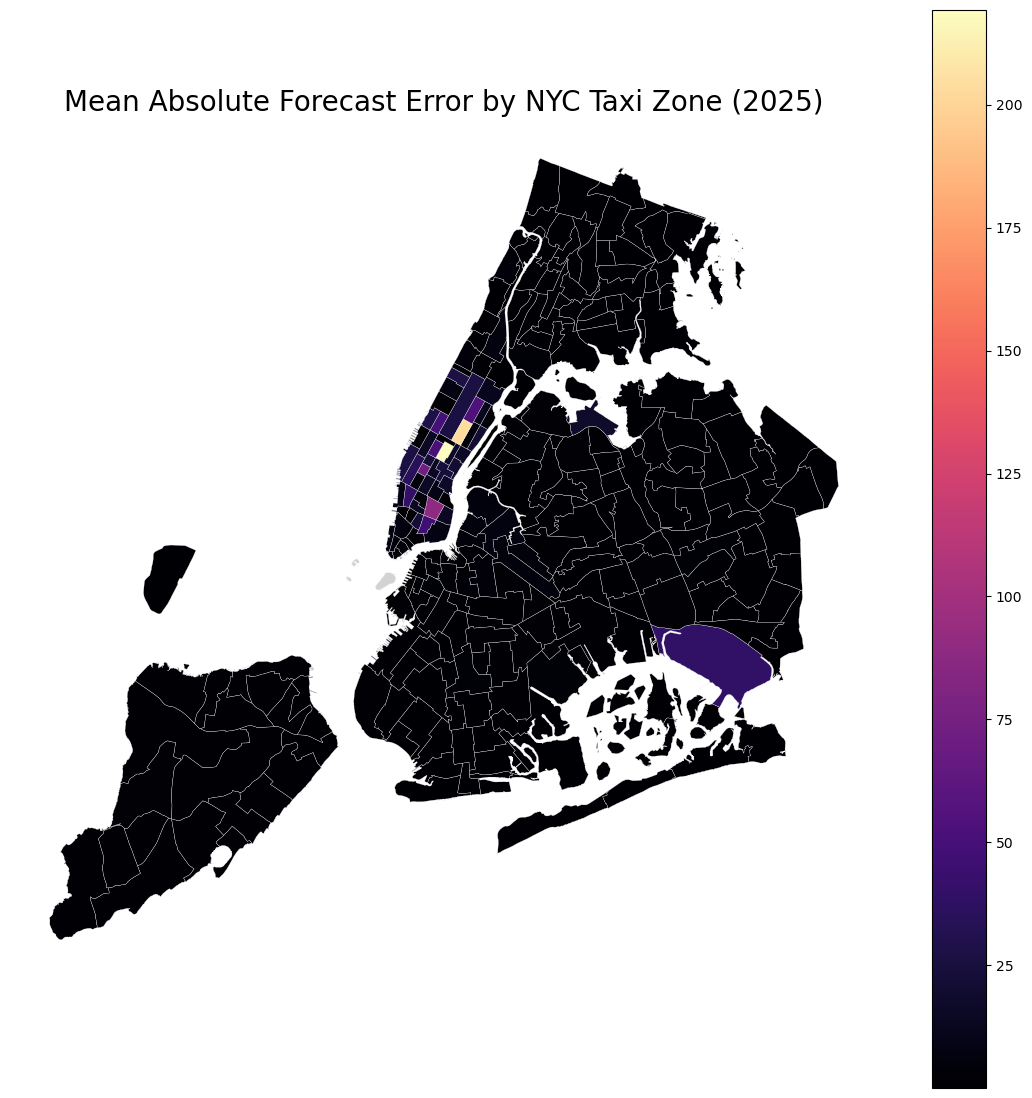

In [191]:
fig, ax = plt.subplots(figsize=(14, 14))

zone_map.plot(
    column="abs_mean_residual",
    cmap="magma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Mean Absolute Forecast Error by NYC Taxi Zone (2025)", fontsize=20)
ax.axis("off")

plt.show()

# Final Model Evaluation: Spatial-Temporal Forecasting on True Holdout Data (2026 Q1)

In [221]:
spatial_2026_files = sorted(
    Path(data_path).glob("yellow_tripdata_2026-*.parquet")
)

[file.name for file in spatial_2026_files]

['yellow_tripdata_2026-01.parquet',
 'yellow_tripdata_2026-02.parquet',
 'yellow_tripdata_2026-03.parquet']

In [222]:
zone_2026_dfs = []

for file in spatial_2026_files:

    print(f"Processing {file.name}")

    df = pd.read_parquet(file)

    # Ensure datetime
    df["tpep_pickup_datetime"] = pd.to_datetime(
        df["tpep_pickup_datetime"]
    )

    # Keep only rows truly belonging to file month
    file_month = file.stem.replace("yellow_tripdata_", "")

    df = df[
        df["tpep_pickup_datetime"]
        .dt.to_period("M")
        .astype(str)
        == file_month
    ].copy()

    # Basic cleaning
    df = df[
        (df["trip_distance"] > 0) &
        (df["fare_amount"] > 0) &
        (df["PULocationID"].notna())
    ].copy()

    # Create date
    df["date"] = (
        df["tpep_pickup_datetime"]
        .dt.floor("D")
    )

    # Aggregate daily by zone
    daily_zone = (
        df
        .groupby(["date", "PULocationID"])
        .agg(
            trip_count=("tpep_pickup_datetime", "count"),
            avg_fare=("fare_amount", "mean"),
            avg_distance=("trip_distance", "mean")
        )
        .reset_index()
    )

    zone_2026_dfs.append(daily_zone)

Processing yellow_tripdata_2026-01.parquet
Processing yellow_tripdata_2026-02.parquet
Processing yellow_tripdata_2026-03.parquet


In [223]:
zone_2026_df = pd.concat(
    zone_2026_dfs,
    ignore_index=True
)

zone_2026_df["date"] = pd.to_datetime(
    zone_2026_df["date"]
)

zone_2026_df = (
    zone_2026_df
    .sort_values(["PULocationID", "date"])
    .reset_index(drop=True)
)

zone_2026_df.head()

,date,PULocationID,trip_count,avg_fare,avg_distance
0,2026-01-01,1,10,89.100000,4.128000
1,2026-01-02,1,7,77.714286,0.071429
2,2026-01-03,1,9,99.077778,0.157778
3,2026-01-04,1,12,79.283333,2.598333
4,2026-01-05,1,4,154.450000,14.677500


In [224]:
taxi_lookup = pd.read_csv(
    data_path / "taxi_zones" / "taxi_zone_lookup.csv"
)

taxi_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [225]:
zone_2026_df = zone_2026_df.merge(
    taxi_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_2026_df.head()

,date,PULocationID,trip_count,avg_fare,avg_distance,LocationID,Borough,Zone,service_zone
0,2026-01-01,1,10,89.100000,4.128000,1,EWR,Newark Airport,EWR
1,2026-01-02,1,7,77.714286,0.071429,1,EWR,Newark Airport,EWR
2,2026-01-03,1,9,99.077778,0.157778,1,EWR,Newark Airport,EWR
3,2026-01-04,1,12,79.283333,2.598333,1,EWR,Newark Airport,EWR
4,2026-01-05,1,4,154.450000,14.677500,1,EWR,Newark Airport,EWR


In [226]:
zone_2026_df["day_of_week"] = (
    zone_2026_df["date"].dt.dayofweek
)

zone_2026_df["month"] = (
    zone_2026_df["date"].dt.month
)

zone_2026_df["is_weekend"] = (
    zone_2026_df["day_of_week"] >= 5
).astype(int)

zone_2026_df["week_of_year"] = (
    zone_2026_df["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

In [230]:
zone_2026_df = zone_2026_df.dropna(
    subset=["Zone", "Borough"]
).copy()

In [231]:
zone_2026_df["zone_encoded"] = (
    zone_encoder.transform(
        zone_2026_df["Zone"]
    )
)

zone_2026_df["borough_encoded"] = (
    borough_encoder.transform(
        zone_2026_df["Borough"]
    )
)

In [232]:
zone_2026_df = (
    zone_2026_df
    .sort_values(["PULocationID", "date"])
)

zone_2026_df["lag_1"] = (
    zone_2026_df
    .groupby("PULocationID")["trip_count"]
    .shift(1)
)

zone_2026_df["lag_7"] = (
    zone_2026_df
    .groupby("PULocationID")["trip_count"]
    .shift(7)
)

zone_2026_df["rolling_mean_7"] = (
    zone_2026_df
    .groupby("PULocationID")["trip_count"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [233]:
zone_2026_df = (
    zone_2026_df
    .dropna(subset=[
        "lag_1",
        "lag_7",
        "rolling_mean_7"
    ])
)

In [234]:
spatial_features = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "avg_fare",
    "avg_distance",
    "borough_encoded",
    "zone_encoded"
]

In [235]:
X_zone_2026 = zone_2026_df[
    spatial_features
]

y_zone_2026 = zone_2026_df[
    "trip_count"
]

In [238]:
zone_panel_model["week_of_year"] = (
    zone_panel_model["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

In [239]:
final_spatial_hgb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

final_spatial_hgb.fit(
    zone_panel_model[spatial_features],
    zone_panel_model["trip_count"]
)

HistGradientBoostingRegressor(learning_rate=0.05, max_depth=10, max_iter=300,
                              random_state=42)

In [240]:
zone_2026_pred = final_spatial_hgb.predict(
    X_zone_2026
)

## Model eval

In [241]:
zone_2026_mae = mean_absolute_error(
    y_zone_2026,
    zone_2026_pred
)

zone_2026_rmse = root_mean_squared_error(
    y_zone_2026,
    zone_2026_pred
)

print("Spatial-Temporal Forecast Performance (2026 Q1)")
print(f"MAE: {zone_2026_mae:,.2f}")
print(f"RMSE: {zone_2026_rmse:,.2f}")

Spatial-Temporal Forecast Performance (2026 Q1)
MAE: 61.64
RMSE: 196.24


In [243]:
zone_2026_forecast = zone_2026_df.copy()

In [244]:
zone_2026_forecast["predicted_trips"] = (
    zone_2026_pred
)

In [245]:
zone_2026_forecast["residual"] = (
    zone_2026_forecast["trip_count"]
    - zone_2026_forecast["predicted_trips"]
)

In [246]:
zone_2026_results = (
    zone_2026_forecast
    .groupby(
        ["PULocationID", "Zone", "Borough"]
    )
    .agg(
        actual_trips=("trip_count", "sum"),
        predicted_trips=("predicted_trips", "sum"),
        mean_abs_error=(
            "residual",
            lambda x: np.mean(np.abs(x))
        )
    )
    .reset_index()
)

zone_2026_results.head()

,PULocationID,Zone,Borough,actual_trips,predicted_trips,mean_abs_error
0,1,Newark Airport,EWR,288,673.801438,6.077095
1,2,Jamaica Bay,Queens,17,66.877159,5.078790
2,3,Allerton/Pelham Gardens,Bronx,1283,1333.140935,4.364001
3,4,Alphabet City,Manhattan,42108,41074.179084,115.525578
4,6,Arrochar/Fort Wadsworth,Staten Island,232,143.818548,3.516342


In [247]:
zone_2026_map = taxi_zones.merge(
    zone_2026_results,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

In [248]:
zone_2026_map["log_actual"] = np.log1p(
    zone_2026_map["actual_trips"]
)

zone_2026_map["log_predicted"] = np.log1p(
    zone_2026_map["predicted_trips"]
)

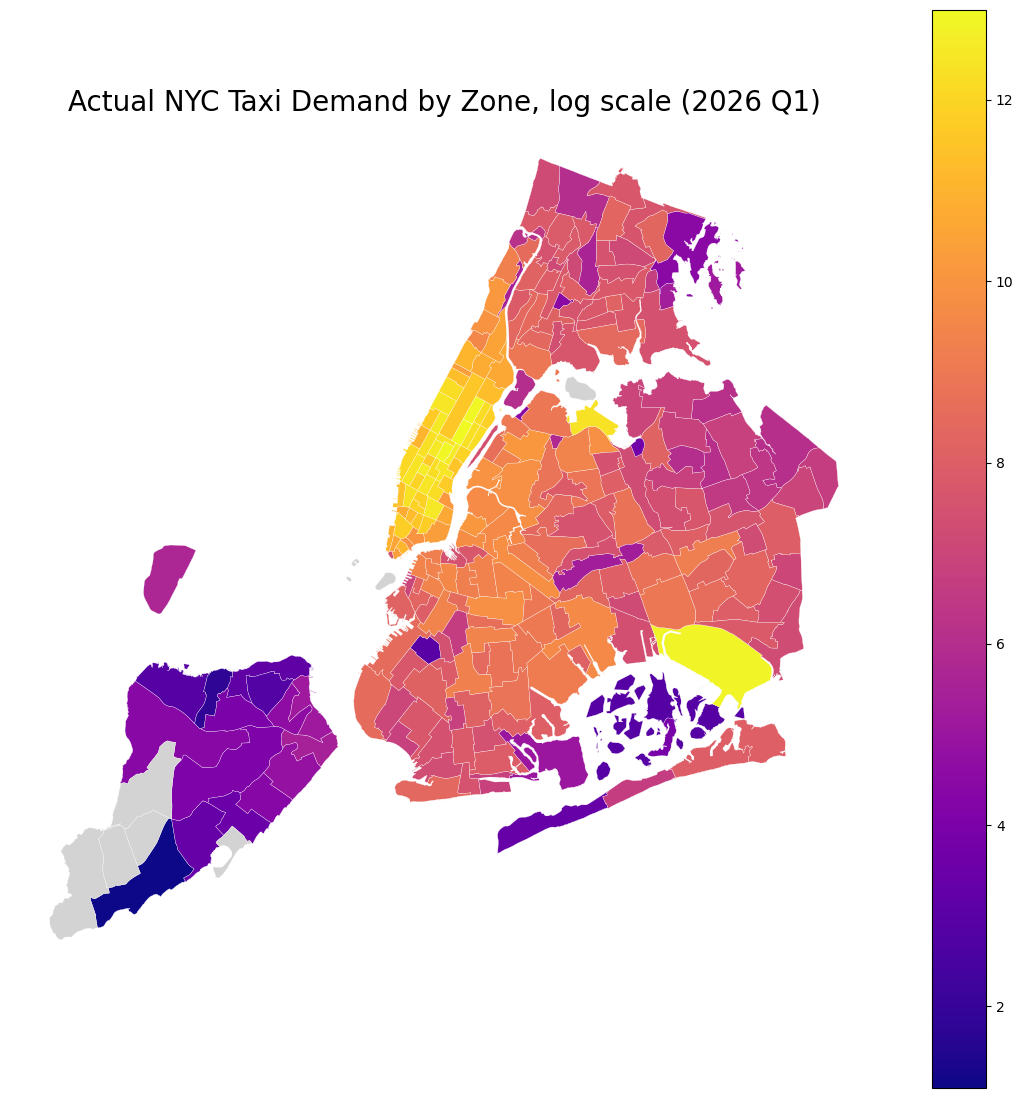

In [249]:
fig, ax = plt.subplots(figsize=(14, 14))

zone_2026_map.plot(
    column="log_actual",
    cmap="plasma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    "Actual NYC Taxi Demand by Zone, log scale (2026 Q1)",
    fontsize=20
)

ax.axis("off")

plt.show()

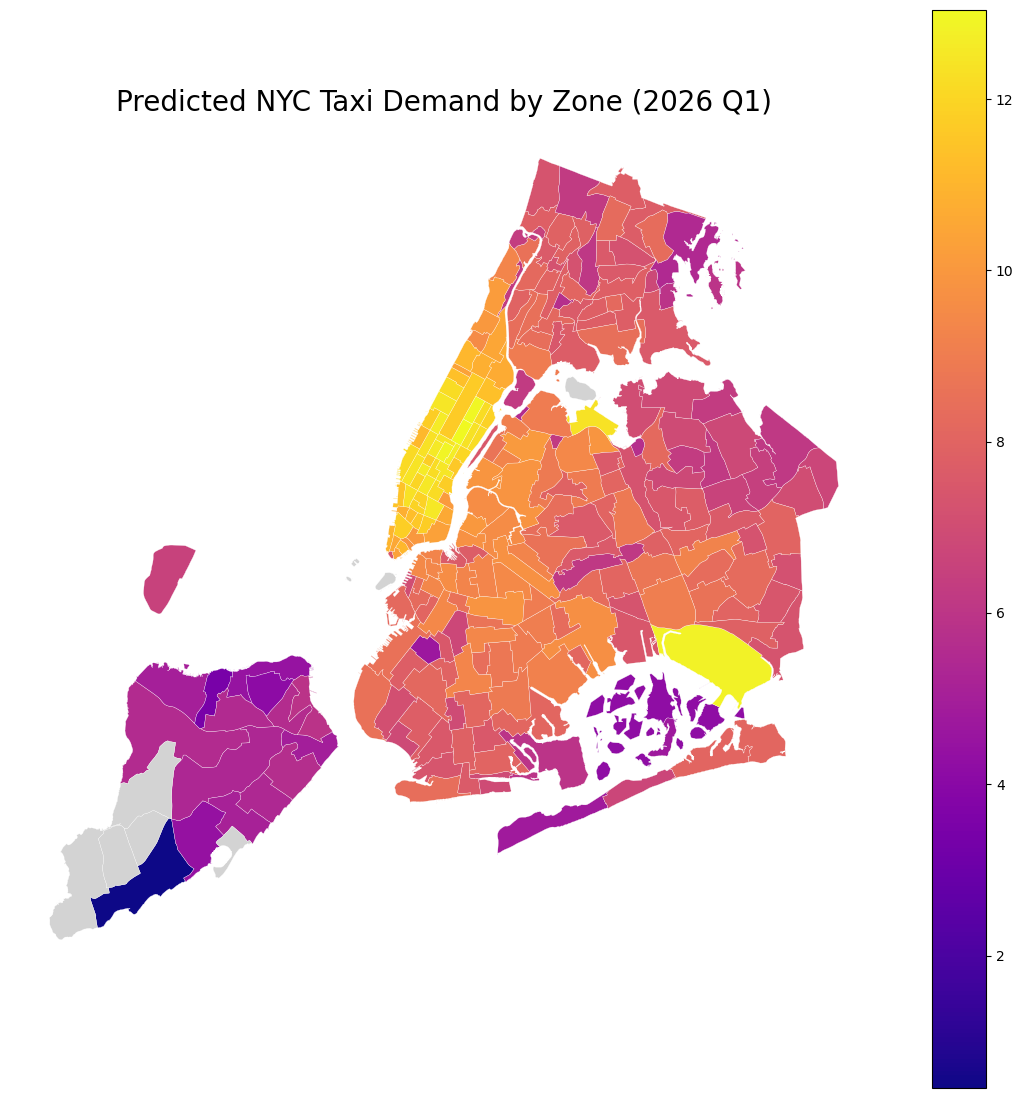

In [264]:
fig, ax = plt.subplots(figsize=(14, 14))

zone_2026_map.plot(
    column="log_predicted",
    cmap="plasma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    "Predicted NYC Taxi Demand by Zone (2026 Q1)",
    fontsize=20
)

ax.axis("off")

plt.show()

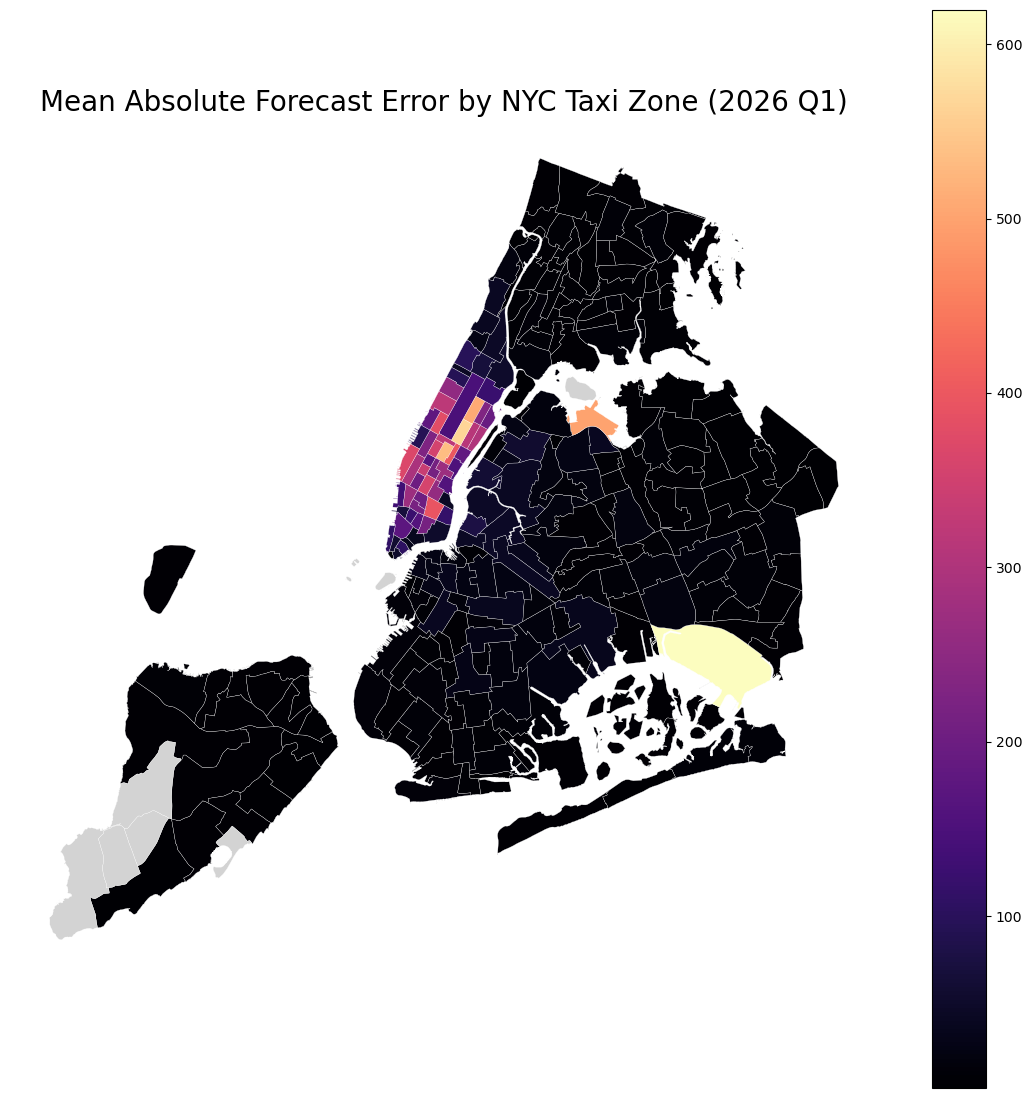

In [251]:
fig, ax = plt.subplots(figsize=(14, 14))

zone_2026_map.plot(
    column="mean_abs_error",
    cmap="magma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    "Mean Absolute Forecast Error by NYC Taxi Zone (2026 Q1)",
    fontsize=20
)

ax.axis("off")

plt.show()

# Feature importance plot

In [256]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_spatial_hgb,
    X_zone_2026,
    y_zone_2026,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [257]:
importance_df = pd.DataFrame({
    "feature": spatial_features,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
1,lag_7,0.491481
0,lag_1,0.271849
2,rolling_mean_7,0.028633
3,day_of_week,0.011881
8,avg_distance,0.004480
10,zone_encoded,0.003483
7,avg_fare,0.003227
5,week_of_year,0.000537
9,borough_encoded,0.000109
4,month,0.000086


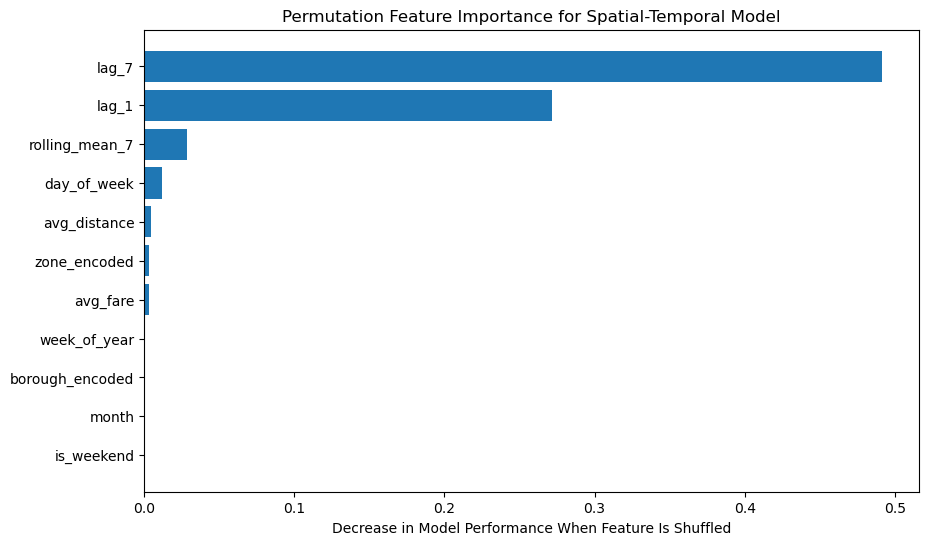

In [258]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance for Spatial-Temporal Model")
plt.xlabel("Decrease in Model Performance When Feature Is Shuffled")

plt.show()